<a href="https://colab.research.google.com/github/Alenushka2013/ML_for_people_tasks/blob/main/HW_3_2_Dimensionality_reduction_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [1]:
import pandas as pd

# 1. Завантаження даних
path = 'https://raw.githubusercontent.com/Alenushka2013/Coursera/refs/heads/master/Datasets/marketing_campaign.csv'
df = pd.read_csv(path, sep = '\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [2]:
# 1. Вибір ключових характеристик
main_columns = ['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases', 'days_lifetime', 'years_customer', 'NumWebVisitsMonth']
X_new = X[main_columns]

# 2. Стандартизація даних
from sklearn.preprocessing import StandardScaler

# Масштабуємо дані
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

# 3. Кластеризація
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.predict(X_scaled)

# 4. Пониження розмірності
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=1)
pca.fit(X_scaled)

# 5. Візуалізація результатів
import plotly.express as px

pca_digits = pca.fit_transform(X_scaled)

# Create a DataFrame for Plotly Express
df = pd.DataFrame(data=pca_digits, columns=['PC1', 'PC2', 'PC3'])
df['target'] = labels

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x='PC1',
    y='PC2',
    z='PC3',
    hover_data='target',
    color='target',
    title='3D Scatter Plot with PCA'
)

# Show the figure
fig.show()

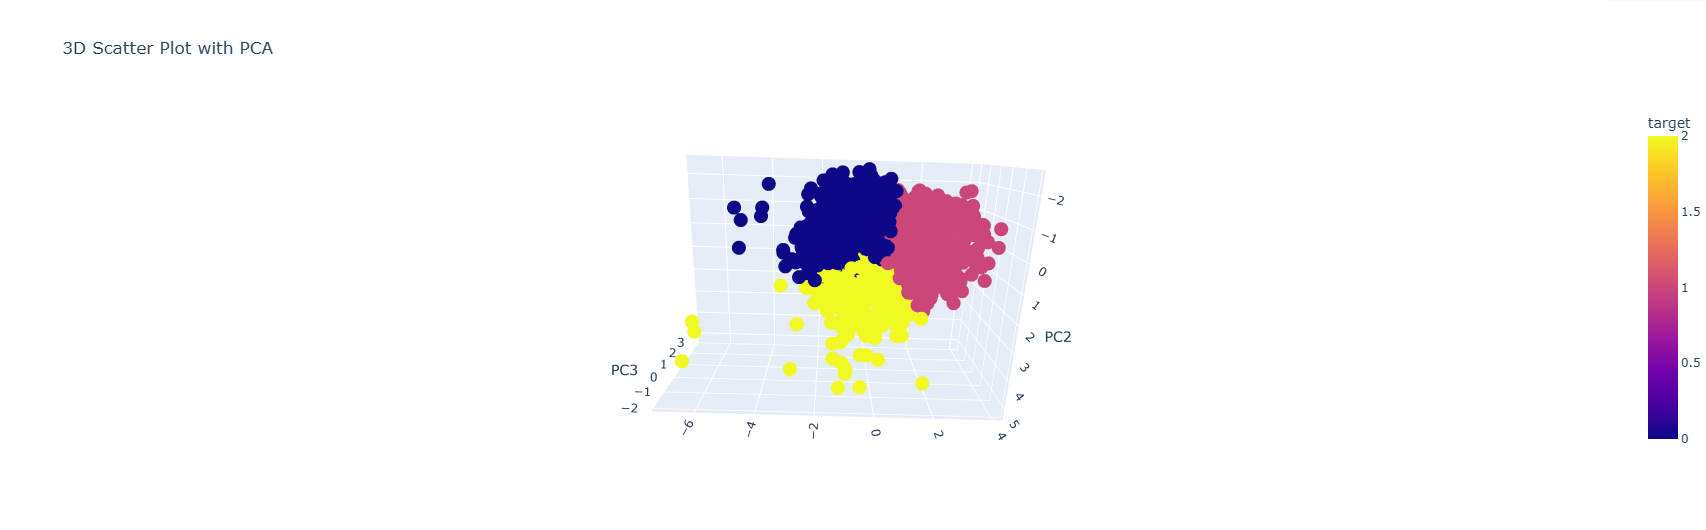

**Спостереження:**

На візуалізації дуже гарно видно розподіл на 3 кластери.

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

Частка поясненої дисперсії для головних компонент:
PC1 = 0.31847 ~ 31.8%
PC2 = 0.19659 ~ 19.7%
PC3 = 0.14339 ~ 14.3%


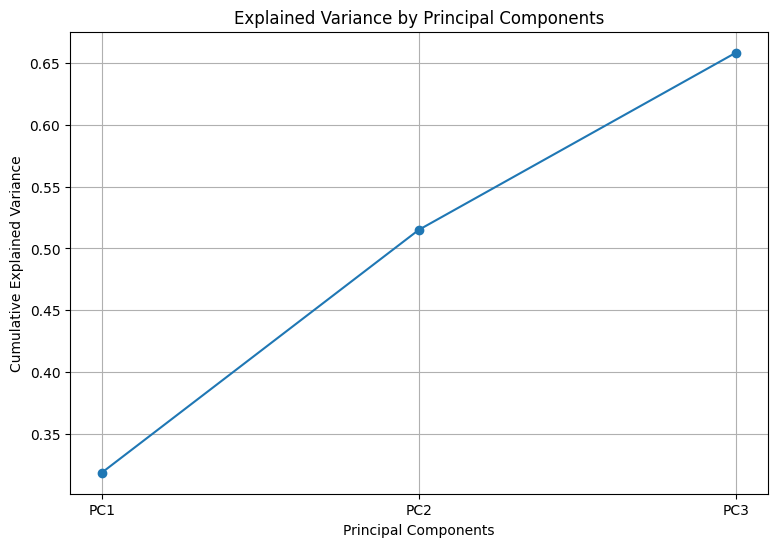

In [3]:
# 1. Розрахунок частки поясненої дисперсії
PC1, PC2, PC3 = pca.explained_variance_ratio_
print('Частка поясненої дисперсії для головних компонент:')
print(f'PC1 = {PC1:.5f} ~ {PC1*100:.1f}%')
print(f'PC2 = {PC2:.5f} ~ {PC2*100:.1f}%')
print(f'PC3 = {PC3:.5f} ~ {PC3*100:.1f}%')


# 2. Розрахунок кумулятивної частки поясненої дисперсії
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

# Задаємо мітки та підписи
n_components = len(pca.explained_variance_ratio_)
plt.xticks(
    ticks=np.arange(n_components),              # позиції
    labels=[f'PC{i+1}' for i in range(n_components)]  # підписи
)

plt.xlabel('Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.show()

### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [4]:
# Матриця loadings
loadings = pd.DataFrame(
    pca.components_.T,   # транспонована матриця, щоб рядки = ознаки
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=main_columns
)

print("Loadings (вплив ознак на головні компоненти):")
display(loadings.round(3))

Loadings (вплив ознак на головні компоненти):


,PC1,PC2,PC3
Income,0.584,0.165,-0.044
Recency,0.010,0.037,0.976
NumStorePurchases,0.489,0.385,-0.081
NumDealsPurchases,-0.199,0.608,-0.035
days_lifetime,-0.133,0.603,-0.022
years_customer,0.189,0.209,0.193
NumWebVisitsMonth,-0.572,0.216,-0.016


**Інтерпретація головних компонент (PCA)**

**PC1** (пояснює найбільшу частку дисперсії ≈ 32%)

Найбільші позитивні навантаження: Income (0.584), NumStorePurchases (0.489)

Найбільший негативний вплив: NumWebVisitsMonth (-0.572)

Ця компонента відображає поведінку клієнтів із високим доходом та активними покупками в магазинах, на противагу клієнтам, які більше взаємодіють із сайтом.

**PC2** (≈ 20%)

Найбільші навантаження: NumDealsPurchases (0.608), days_lifetime (0.603), NumStorePurchases (0.385)

 PC2 відображає орієнтацію на знижки та тривалість перебування у компанії. Її можна трактувати як компоненту, що відділяє клієнтів із довготривалим стажем і схильністю до акційних покупок від інших.

**PC3** (≈ 14%)

Абсолютний лідер: Recency (0.976)

PC3 майже повністю визначається показником Recency — тобто часом від останньої покупки. Вона чітко виділяє клієнтів за активністю покупок у часі (часто купують vs давно не купували).

###Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [5]:
# 1. Видалення ознаки Income
features_no_income = ['Recency', 'NumStorePurchases',
                      'NumDealsPurchases', 'days_lifetime',
                      'years_customer', 'NumWebVisitsMonth']

X_no_income = X[features_no_income]

# Стандартизація
scaler = StandardScaler()
X_scaled_no_income = scaler.fit_transform(X_no_income)

# 2. Обчислення нових навантажень для головних компонент
pca_no_income = PCA(n_components=3, random_state=1)
pca_no_income.fit(X_scaled_no_income)

# Обчислення loadings
import pandas as pd
loadings_no_income = pd.DataFrame(
    pca_no_income.components_.T,
    columns=[f'PC{i+1}' for i in range(3)],
    index=features_no_income
)
print("Loadings без Income:")
display(loadings_no_income.round(3))

# 3. Які ознаки мають найбільший вплив на кожну головну компоненту
explained_var = pca_no_income.explained_variance_ratio_
print("\nЧастка поясненої дисперсії:")
for i, var in enumerate(explained_var, start=1):
    print(f"PC{i}: {var:.4f} ~ {var*100:.1f}%")

print("\nКумулятивна частка:", explained_var.sum().round(5))

# 4. Пояснення дисперсії в даних без ознаки Income

Loadings без Income:


,PC1,PC2,PC3
Recency,-0.014,0.075,0.990
NumStorePurchases,-0.381,0.629,-0.111
NumDealsPurchases,0.446,0.462,-0.062
days_lifetime,0.384,0.468,0.007
years_customer,-0.177,0.394,0.056
NumWebVisitsMonth,0.691,-0.108,0.010



Частка поясненої дисперсії:
PC1: 0.2739 ~ 27.4%
PC2: 0.2144 ~ 21.4%
PC3: 0.1668 ~ 16.7%

Кумулятивна частка: 0.65522


**Інтерпретація головних компонент після вилучення Income**

**PC1** (пояснює найбільшу частку дисперсії ≈ 27%)

Найбільший позитивний вплив: NumWebVisitsMonth (0.691), NumDealsPurchases (0.446), days_lifetime (0.384).

Найбільший негативний вплив: NumStorePurchases (-0.381).

PC1 описує поведінку клієнтів, які часто відвідують сайт і роблять покупки зі знижками, на противагу тим, хто більше орієнтований на покупки у магазинах.

**PC2** (≈ 21%)

Найбільші навантаження: NumStorePurchases (0.629), NumDealsPurchases (0.462), days_lifetime (0.468), years_customer (0.394).

PC2 можна інтерпретувати як компоненту лояльності й досвіду: вона пов’язана з частотою покупок у магазинах, стажем у компанії та схильністю до акційних покупок.

**PC3** (≈ 17%)

Абсолютний домінант: Recency (0.990).

PC3 повністю відображає давність останньої покупки: клієнти, які купували недавно, відділяються від тих, хто давно не проявляв активності.

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

In [6]:
from sklearn.manifold import TSNE
# 1. t-SNE для зниження розмірності до 2х вимірів
tsne = TSNE(n_components=2,random_state=1)
X_tsne = tsne.fit_transform(X_scaled)

# 2. створюємо DataFrame з координатами та кластерами
tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:,0],
    'TSNE2': X_tsne[:,1],
    'Cluster': labels
})




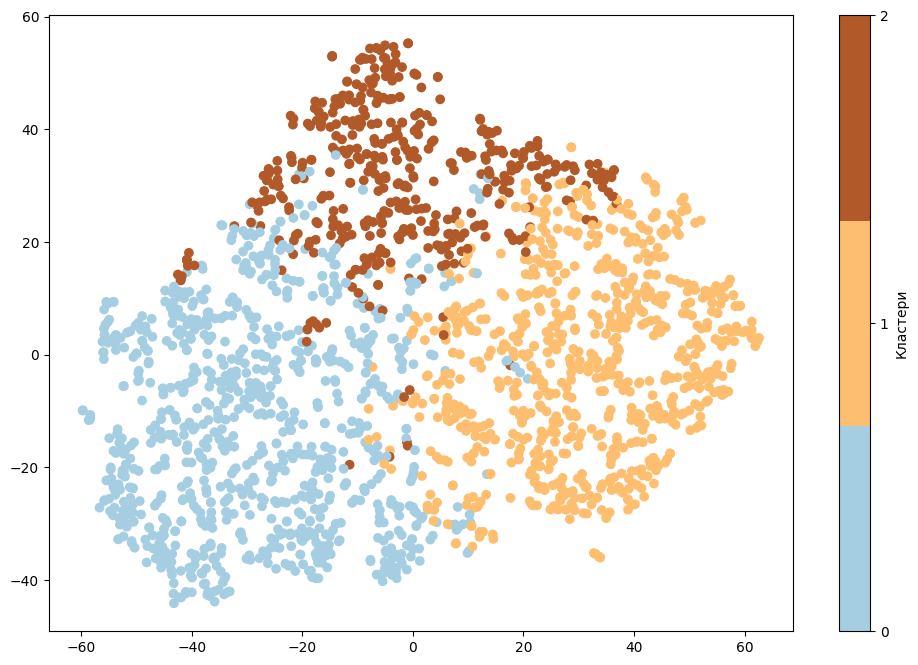

In [7]:
%matplotlib inline
from sklearn.manifold import TSNE

#tsne = TSNE(n_components=2, random_state=0)
#tsne_digits = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    tsne_df.iloc[:, 0],
    tsne_df.iloc[:, 1],
    c=labels,
    cmap=plt.get_cmap('Paired', 3)
)

cbar = plt.colorbar(scatter, ticks=range(3))
cbar.set_label('Кластери')
plt.show()

In [8]:
# Об'єднуємо t-SNE координати з ознаками
X_scaled_df = pd.DataFrame(X_scaled, columns=main_columns)
tsne_full = pd.concat([tsne_df, X_scaled_df.reset_index(drop=True)], axis=1)

fig = px.scatter(
    tsne_full,
    x='TSNE1',
    y='TSNE2',
    color='Cluster',
    hover_data=X_scaled_df.columns,  # тепер ці колонки є в tsne_full
    title="t-SNE кластеризація з ознаками"
)
fig.show()


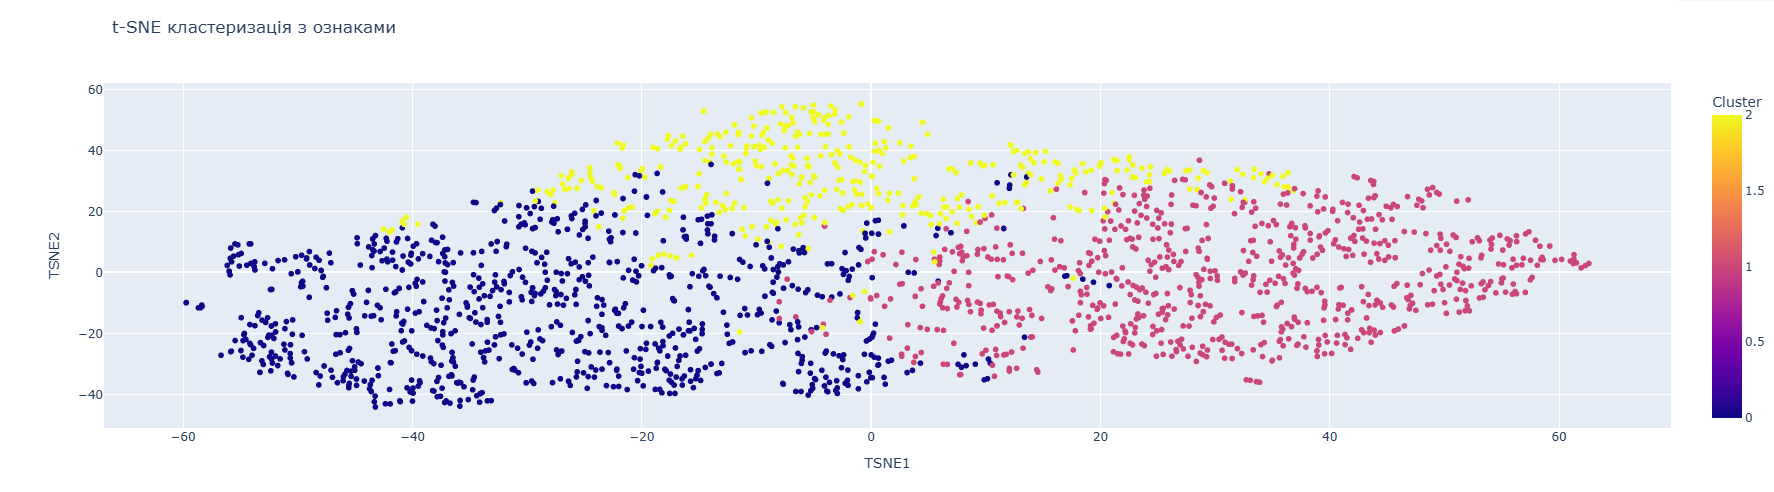

In [9]:
cluster_means = tsne_full.groupby('Cluster').mean()

pd.DataFrame(cluster_means)

,TSNE1,TSNE2,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
Cluster,,,,,,,,,
0,-27.486115,-12.323463,-0.831726,-0.021105,-0.804365,-0.265331,-0.204146,-0.273557,0.490625
1,30.671583,-1.389693,0.958037,0.007737,0.784516,-0.456525,-0.189551,0.179395,-0.926969
2,-2.335958,31.232149,0.023791,0.030582,0.279863,1.386163,0.774033,0.253289,0.640450


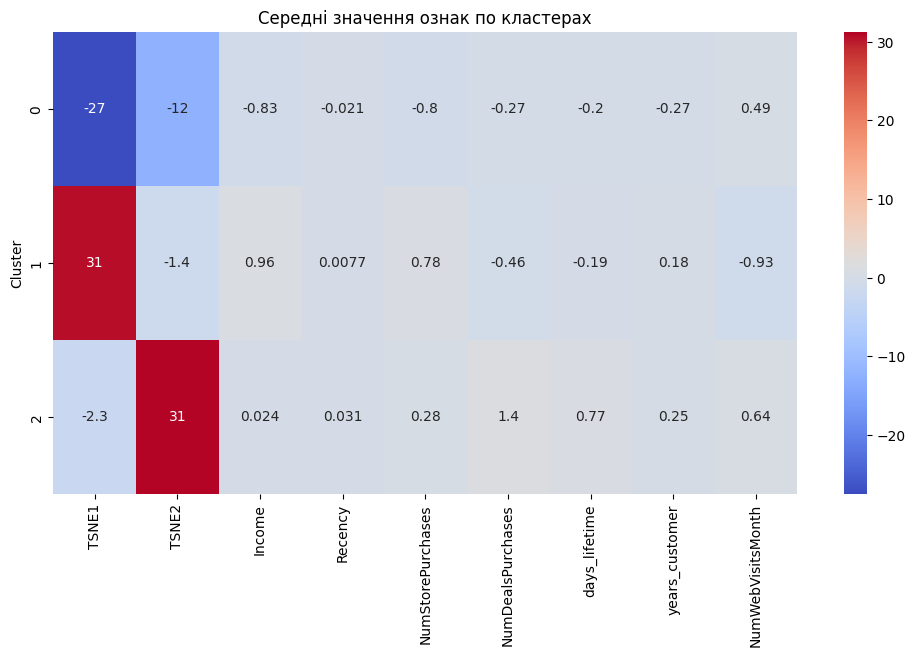

In [10]:
import seaborn as sns

cluster_profiles = pd.DataFrame(tsne_full).groupby(labels).mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm')
plt.title("Середні значення ознак по кластерах")
plt.show()

In [11]:
# відсортуємо за найбільшим відхиленням
top_features = cluster_means.T.apply(lambda x: x.abs()).sort_values(by=[0,1,2], ascending=False).head(10)
top_features


Cluster,0,1,2
TSNE1,27.486115,30.671583,2.335958
TSNE2,12.323463,1.389693,31.232149
Income,0.831726,0.958037,0.023791
NumStorePurchases,0.804365,0.784516,0.279863
NumWebVisitsMonth,0.490625,0.926969,0.640450
years_customer,0.273557,0.179395,0.253289
NumDealsPurchases,0.265331,0.456525,1.386163
days_lifetime,0.204146,0.189551,0.774033
Recency,0.021105,0.007737,0.030582


**Аналіз кластерів**

**Cluster 0**

Income = 0.83 → високий дохід

NumStorePurchases = 0.80 → часто купують офлайн у магазинах

NumWebVisitsMonth = 0.49 → помірна активність на сайті

NumDealsPurchases = 0.27 → іноді реагують на акції

days_lifetime / years_customer ≈ середні значення

 Це заможні клієнти, які віддають перевагу класичним покупкам у магазині, онлайн використовують помірно, акціями цікавляться мало.
Рекомендація: утримувати через персональні програми лояльності, VIP-сервіс.

**Cluster 1**

Income = 0.96 → найвищий дохід

NumStorePurchases = 0.78 → багато покупок офлайн

NumWebVisitsMonth = 0.93 → дуже активні онлайн

NumDealsPurchases = 0.46 → більше реагують на акції, ніж кластер 0

Recency ≈ 0 → купували недавно

days_lifetime / years_customer трохи нижчі, ніж у кластерів 0 і 2

Це найбільш заможні клієнти, які активно поєднують онлайн і офлайн, і час від часу користуються акціями.
Рекомендація: інвестувати в цей сегмент — вони цінні, відкриті і до преміум-сервісу, і до онлайн-каналів.

**Cluster 2**

Income ≈ 0.02 → середній дохід

NumDealsPurchases = 1.39 → дуже чутливі до знижок і промоакцій

days_lifetime = 0.77 → довше залишаються клієнтами

NumWebVisitsMonth = 0.64 → активні онлайн

NumStorePurchases = 0.28 → менше купують офлайн

Recency = 0.03 → теж недавні покупки

Це середньодоходні клієнти, які орієнтовані на вигоду (акції/знижки), більш лояльні у часі, ніж заможні групи.
Рекомендація: залучати через акційні пропозиції, бонуси, програми лояльності.